In [61]:
import sklearn 
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.manifold import Isomap
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

import matplotlib.pyplot as plt
import numpy as np

In [2]:
digits = datasets.load_digits()
print(digits.images.shape)
print(digits.keys())

d80, d20, d80_train, d20_test  = train_test_split(digits.data, digits.target, train_size=0.8)
print(d80)
print(d80.shape)

(1797, 8, 8)
dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])
[[ 0.  4. 15. ...  0.  0.  0.]
 [ 0.  0.  9. ...  5.  0.  0.]
 [ 0.  0. 11. ...  5. 16.  1.]
 ...
 [ 0.  0.  0. ... 16. 12.  0.]
 [ 0.  0.  9. ...  0.  0.  0.]
 [ 0.  0.  3. ... 16.  9.  0.]]
(1437, 64)


In [25]:
embedding = Isomap(n_components=40)
x = embedding.fit_transform(d80)
x_test = embedding.fit_transform(d20)


/home/matti/uni/lab/myenv/lib/python3.12/site-packages/sklearn/manifold/_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/home/matti/uni/lab/myenv/lib/python3.12/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


In [ ]:
print ('x train shape:', x.shape)
print ('y_test shape:', d20.shape)



x train shape (1437, 40)
y_test shape (360, 64)


In [5]:
# fig, axes = plt.subplots(3, 4, figsize=(20, 10))
# for i in range(1, 13):
#     axes.flat[i-1].scatter(prova[:, 0], prova[:, i])
#     axes.flat[i-1].set_title(f'Axis 0 vs {i}')
# plt.tight_layout()
# plt.show()

In [27]:
clf = LogisticRegression(random_state=42, solver = 'sag')
clf.fit(x, d80_train)

/home/matti/uni/lab/myenv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [37]:
y_predict = clf.predict(x_test[:,:])
# print(y_predict)
print('accuracy score y_test-y_predict',accuracy_score(d20_test, y_predict), '\n')
print(confusion_matrix(d20_test, y_pred = y_predict))

accuracy score y_test-y_predict 0.4388888888888889 

[[32  0  0  0  0  0 10  0  0  0]
 [ 1  2  1  0  0  0  0  0 19  4]
 [ 0  0 31  2  0  0  0  0  3  2]
 [ 0  0  2  0 38  0  0  0  5  0]
 [ 0  0  0  4  0  6  0  2  1 25]
 [ 0  0  0  0  9 23 11  0  0  0]
 [ 0  1  0  0  0  0 29  0  1  0]
 [ 0  0  0  0  0  0  0 31  0  0]
 [ 0 13  0  7  0  1  0  1  8  2]
 [ 8  1 14  2  2  0  0  4  0  2]]


/tmp/ipykernel_16350/1561638395.py:1: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(confusion_matrix(d20_test, y_predict)),


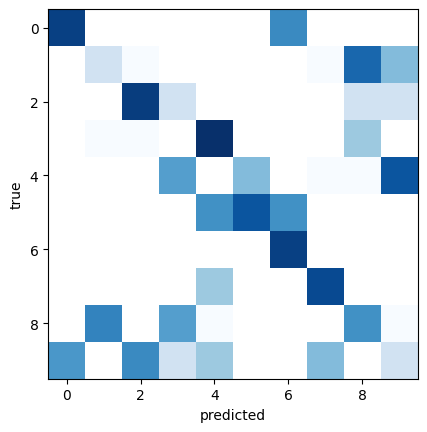

In [69]:
plt.imshow(np.log(confusion_matrix(d20_test, y_predict)), 
           cmap='Blues', interpolation='nearest');
plt.ylabel('true')
plt.xlabel('predicted');

# n_comp = 2

In [38]:
embedding = Isomap(n_components=2)
x = embedding.fit_transform(d80)
x_test = embedding.fit_transform(d20)

/home/matti/uni/lab/myenv/lib/python3.12/site-packages/sklearn/manifold/_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/home/matti/uni/lab/myenv/lib/python3.12/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


In [39]:
clf = LogisticRegression(random_state=42, solver = 'sag')
clf.fit(x, d80_train)

/home/matti/uni/lab/myenv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [58]:
y_predict = clf.predict(x_test[:,:])
# print(y_predict)
print('accuracy score y_test-y_predict',accuracy_score(d20_test, y_predict), '\n')
print( confusion_matrix(d20_test, y_pred = y_predict))

accuracy score y_test-y_predict 0.4027777777777778 

[[30  0  0  0  0  0 12  0  0  0]
 [ 1  7  4  2  0  0  0  0 10  3]
 [ 0  0 22  5  0  0  0  0  9  2]
 [ 0  0  2  0 39  0  0  0  4  0]
 [ 0  0  0  2  0  5  0  5  0 26]
 [ 0  0  0  0  7 25 11  0  0  0]
 [ 0  1  0  0  0  0 29  0  1  0]
 [ 0  0  0  0  6  0  0 25  0  0]
 [ 0 13  0 10  1  0  0  1  5  2]
 [ 7  1 15  1  2  0  0  5  0  2]]


/tmp/ipykernel_16350/1561638395.py:1: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(confusion_matrix(d20_test, y_predict)),


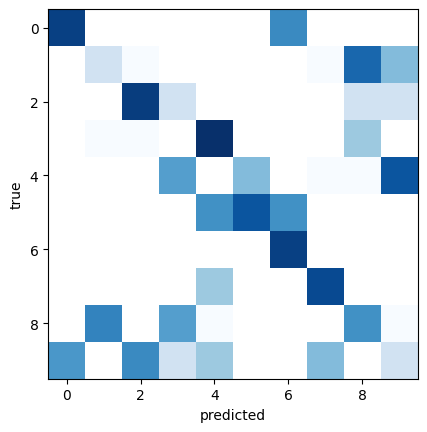

In [68]:
plt.imshow(np.log(confusion_matrix(d20_test, y_predict)), 
           cmap='Blues', interpolation='nearest');
plt.ylabel('true')
plt.xlabel('predicted');

# ciclo

In [ ]:
results = np.zeros(58)
for i in range (58):
    embedding = Isomap(n_components=i + 1)
    x = embedding.fit_transform(d80)
    x_test = embedding.fit_transform(d20)
    clf = LogisticRegression(random_state=0, solver = 'sag')
    clf.fit(x, d80_train)
    y_predict = clf.predict(x_test[:,:])
    results[i] = accuracy_score(d20_test, y_predict)
# print(y_predict)
    # print(f'accuracy score y_test-y_predict {(i + 1)}',accuracy_score(d20_test, y_predict), '\n')
# print(confusion_matrix(d20_test, y_pred = y_predict))
    

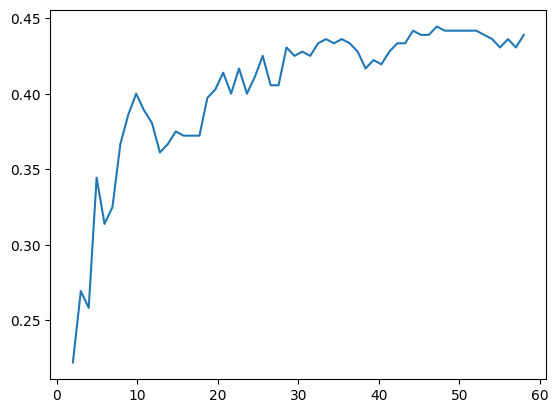

In [67]:
x0 = np.linspace(2, 58, 58)
plt.plot(x0, results)